# XGBoost Regression Model

XGBoost model to predict solar energy output using GDP, population, and GDP per capita.

In [12]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor


## 1. Load and Prepare the Dataset


In [13]:
# Load the dataset
df = pd.read_csv("../data/World Energy Consumption.csv")


df = df.dropna(subset=['gdp', 'population', 'solar_consumption'])
df['gdp_per_capita'] = df['gdp'] / df['population']
df = df[df['solar_consumption'] > 0].copy()


## 2. Define Features and Target


In [14]:
X = df[['gdp', 'population', 'gdp_per_capita']]
y = df['solar_consumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Train the XGBoost Regressor


In [15]:
xgb_model = XGBRegressor(random_state=42, n_estimators=100)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)


## 4. Evaluate Model Performance


In [16]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost R² Score: {r2:.2f}")


XGBoost RMSE: 9.92
XGBoost R² Score: 0.86


## 5. Feature Importance


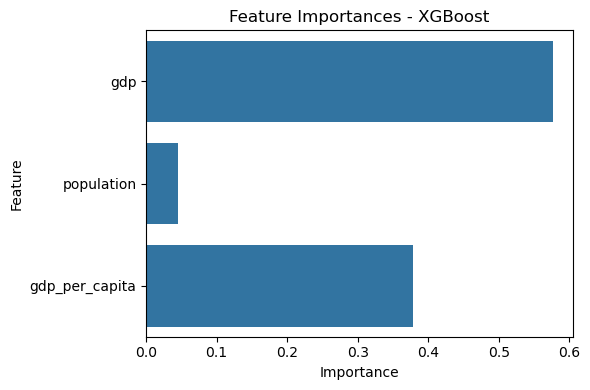

In [17]:
importances = xgb_model.feature_importances_
features = X.columns

plt.figure(figsize=(6, 4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
